# EXPLORATORY DATA ANALYSIS AND LEAD SCORING MODEL: Enpal Heat Pump Conversion Prediction
Dataset: 10,000 customer inquiries
Goal: Understanding patterns driving heat pump purchases in Germany

Key Analysis Areas:
1. Data Quality & Missing Values
2. Class Imbalance Assessment
3. Temporal Patterns (seasonality, trends via temporal fields)
4. Property Characteristics (home age, size, current heating)
5. Customer Demographics (income, region)
6. Sales Lead Quality (channel, contact attempts)
7. Feature Relationships & Correlations
8. Conversion Drivers

## Step 0: Setup and Import

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix, 
    roc_auc_score, average_precision_score,
    precision_recall_curve, roc_curve,
    precision_score, recall_score, f1_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier


import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

In [13]:
#plotting settings
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 10

## Step 1: Data preprocessing and analysis

### 1.DATA LOADING AND INITIAL INSPECTION

In [16]:
csv_path = 'dataset/heat_pump_conversion_dataset.csv'
plot_dir = "plots"
df = pd.read_csv(
    csv_path,
    na_values=["", " ", "NA", "N/A", "null", "None"]
)
print("Dataframe shape:", df.shape)
print("Dataframe columns:", df.columns.tolist())
print("Dataframe data types:", df.dtypes)
print("Dataframe statistics:", df.describe())

Dataframe shape: (10000, 13)
Dataframe columns: ['inquiry_date', 'house_age', 'heating_system', 'house_size_sqm', 'num_rooms', 'household_income', 'postal_region', 'marketing_channel', 'contact_attempts', 'property_value', 'day_of_week', 'energy_consumption_kwh', 'converted']
Dataframe data types: inquiry_date               object
house_age                  object
heating_system             object
house_size_sqm            float64
num_rooms                   int64
household_income          float64
postal_region              object
marketing_channel          object
contact_attempts            int64
property_value            float64
day_of_week                object
energy_consumption_kwh    float64
converted                   int64
dtype: object
Dataframe statistics:        house_size_sqm     num_rooms  household_income  contact_attempts  \
count    10000.000000  10000.000000      10000.000000       10000.00000   
mean       150.311300      5.464000      64358.510000           3.50600  

In [17]:
# Target sanity
df["converted"] = df["converted"].astype(int)
conversion_rate = df["converted"].mean() * 100  # %
print(f"base rate of conversion in the dataset: {conversion_rate}%")
df.head()

base rate of conversion in the dataset: 5.0%


,inquiry_date,house_age,heating_system,house_size_sqm,num_rooms,household_income,postal_region,marketing_channel,contact_attempts,property_value,day_of_week,energy_consumption_kwh,converted
0,2023-04-15,10-30 years,Gas,96.0,4,59600.0,NW,Referral,4,235000.0,Sat,14027.0,0
1,2023-11-21,10-30 years,Oil,157.0,6,30000.0,BE,Display,5,315000.0,Wed,13991.0,0
2,2023-06-23,<10 years,Oil,151.0,5,49000.0,NW,Organic,3,441000.0,Sun,21844.0,0
3,2024-06-21,10-30 years,Oil,242.0,8,99500.0,BY,Paid Social,4,574000.0,Thu,17041.0,0
4,2024-02-03,10-30 years,Gas,177.0,7,89600.0,NW,Organic,5,361000.0,Tue,NaN,0


The target class has high imbalance. Out of 10000 data points, only 500 is converted. 

In [18]:
# Missing values
missing = df.isna().mean().sort_values(ascending=False)
display(missing.to_frame("missing_rate").head(10))

df["energy_missing"] = df["energy_consumption_kwh"].isna().astype(int)
display(df.groupby("energy_missing")["converted"].agg(["mean","count"]))

,missing_rate
energy_consumption_kwh,0.1892
house_age,0.0000
heating_system,0.0000
house_size_sqm,0.0000
inquiry_date,0.0000
num_rooms,0.0000
household_income,0.0000
marketing_channel,0.0000
postal_region,0.0000
contact_attempts,0.0000


,mean,count
energy_missing,,
0,0.057474,8108
1,0.017970,1892


#### Analysing energy_consumption_kwh wrt other columns

In [19]:
#correlating energy_consumption_kwh with the property characteristics
cols = ["house_size_sqm","num_rooms","property_value","energy_consumption_kwh"]
display(df[cols].corr(method="spearman"))

,house_size_sqm,num_rooms,property_value,energy_consumption_kwh
house_size_sqm,1.000000,0.825162,0.882436,-0.004324
num_rooms,0.825162,1.000000,0.729754,0.000440
property_value,0.882436,0.729754,1.000000,0.001172
energy_consumption_kwh,-0.004324,0.000440,0.001172,1.000000


In [20]:
tmp = df.dropna(subset=["energy_consumption_kwh","house_size_sqm"]).copy()
tmp["size_decile"] = pd.qcut(tmp["house_size_sqm"], q=10, duplicates="drop")
display(tmp.groupby("size_decile")["energy_consumption_kwh"].agg(["median","count"]))


,median,count
size_decile,,
"(59.999, 98.7]",14866.0,811
"(98.7, 117.0]",15425.0,825
"(117.0, 129.0]",15472.5,816
"(129.0, 140.0]",15289.0,836
"(140.0, 150.0]",14631.0,809
"(150.0, 160.0]",15080.0,789
"(160.0, 171.0]",14970.5,846
"(171.0, 184.0]",15011.0,794
"(184.0, 202.0]",15304.5,802


In [21]:
#checking energy_consumption_kwh relation with some categorical columns
print(df.groupby("heating_system")["energy_consumption_kwh"].agg(["median","mean","count"]) )
print(df.groupby("house_age")["energy_consumption_kwh"].agg(["median","mean","count"]))


                 median          mean  count
heating_system                              
District        15644.0  15418.693057    821
Electric        15141.5  15047.574523   1154
Gas             15163.0  15071.320814   4127
Oil             15000.5  14953.968594   2006
              median          mean  count
house_age                                
10-30 years  15165.5  15038.716317   4008
<10 years    15302.0  15210.046332   1554
>30 years    15098.5  15046.764729   2546


0.001     5000.000
0.010     5000.000
0.050     6622.550
0.500    15166.500
0.950    23128.450
0.990    26561.270
0.999    30828.728
Name: energy_consumption_kwh, dtype: float64
IQR bounds: 1444.125 28591.125
outliers below: 0
outliers above: 29


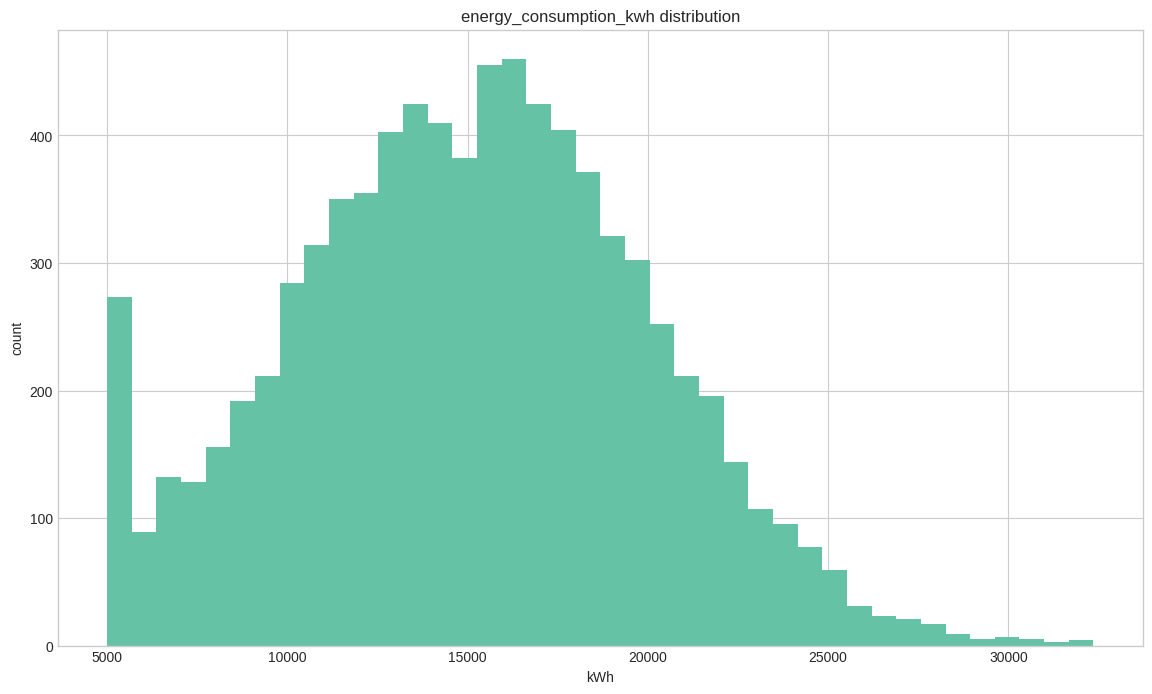

<Figure size 800x400 with 0 Axes>

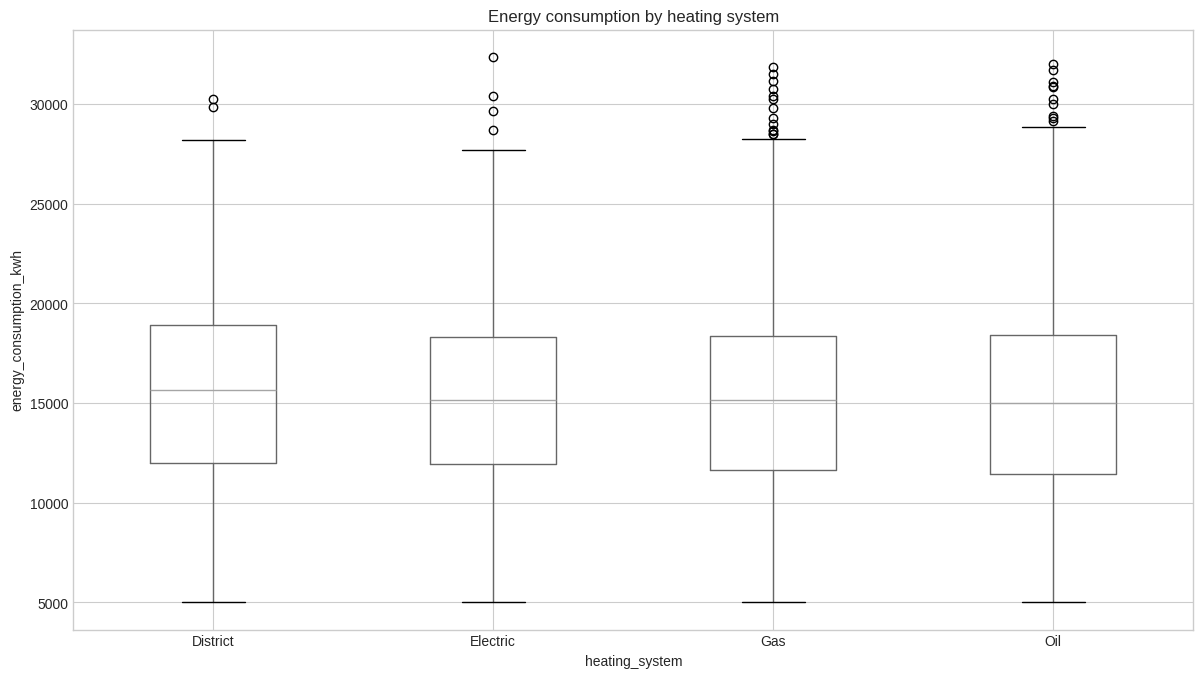

<Figure size 700x400 with 0 Axes>

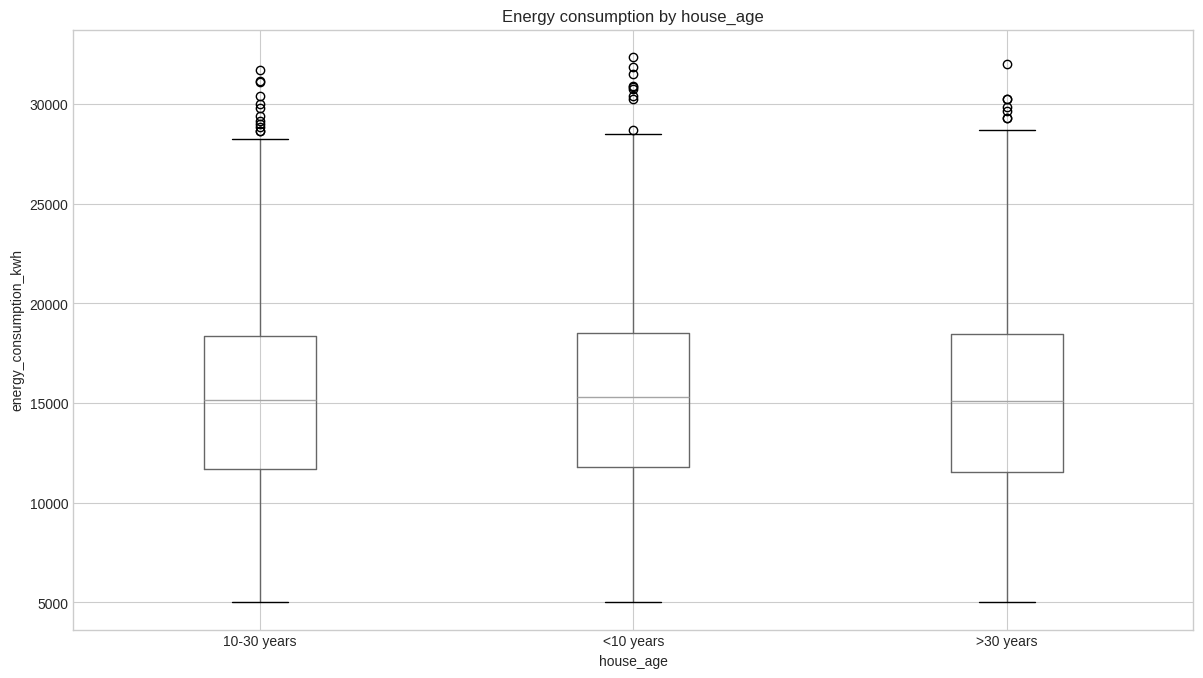

In [25]:
s = df["energy_consumption_kwh"].dropna()

q = s.quantile([0.001, 0.01, 0.05, 0.5, 0.95, 0.99, 0.999])
print(q)

q1, q3 = s.quantile([0.25, 0.75])
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr
print("IQR bounds:", lower, upper)

print("outliers below:", (s < lower).sum())
print("outliers above:", (s > upper).sum())
plt.figure()
s.hist(bins=40)
plt.title("energy_consumption_kwh distribution")
plt.xlabel("kWh")
plt.ylabel("count")
plt.show()
plt.savefig(f'{plot_dir}/01_energy_consumption_kwh_distribution.png', dpi=300, bbox_inches='tight')
plt.close()

plt.figure(figsize=(8,4))
df.boxplot(column="energy_consumption_kwh", by="heating_system")
plt.title("Energy consumption by heating system")
plt.suptitle("")
plt.xlabel("heating_system")
plt.ylabel("energy_consumption_kwh")
plt.savefig(f'{plot_dir}/02_energy_consumption_kwh_dist_heating_system.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

tmp = df.dropna(subset=["energy_consumption_kwh", "house_age"])

plt.figure(figsize=(7,4))
tmp.boxplot(column="energy_consumption_kwh", by="house_age")
plt.title("Energy consumption by house_age")
plt.suptitle("")
plt.xlabel("house_age")
plt.ylabel("energy_consumption_kwh")
plt.savefig(f'{plot_dir}/03_energy_consumption_kwh_dist_house_age.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()


In [26]:
df["sqm_per_room"] = df["house_size_sqm"] / df["num_rooms"].replace(0, np.nan)
df["value_per_sqm"] = df["property_value"] / df["house_size_sqm"].replace(0, np.nan)

In [28]:
#statistics
print(f"\n NUMERICAL FEATURES SUMMARY")
numerical_cols = df.select_dtypes(include=[np.number]).columns.drop('converted')
print(df[numerical_cols].describe().round(2))


 NUMERICAL FEATURES SUMMARY
       house_size_sqm  num_rooms  household_income  contact_attempts  \
count        10000.00   10000.00          10000.00          10000.00   
mean           150.31       5.46          64358.51              3.51   
std             39.74       1.71          26103.32              1.80   
min             60.00       2.00          30000.00              1.00   
25%            123.00       4.00          45500.00              2.00   
50%            150.00       6.00          59450.00              3.00   
75%            177.00       7.00          77200.00              5.00   
max            293.00       8.00         200000.00             10.00   

       property_value  energy_consumption_kwh  energy_missing  sqm_per_room  \
count        10000.00                 8108.00        10000.00      10000.00   
mean        375279.30                15074.08            0.19         28.72   
std         111132.47                 4903.45            0.39          6.58   
min   

In [29]:
print(df["property_value"].quantile([0.001, 0.01, 0.99, 0.999]))
print(df["household_income"].quantile([0.001, 0.01, 0.99, 0.999]))

0.001     64999.0
0.010    121990.0
0.990    638000.0
0.999    744007.0
Name: property_value, dtype: float64
0.001     30000.0
0.010     30000.0
0.990    149102.0
0.999    200000.0
Name: household_income, dtype: float64


In [32]:
df['inquiry_date'] = pd.to_datetime(df['inquiry_date'])

print(f"Data loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Date range: {df['inquiry_date'].min()} to {df['inquiry_date'].max()}")

Data loaded: 10,000 rows × 16 columns
Date range: 2023-01-01 00:00:00 to 2024-12-28 00:00:00


In [33]:
insights = {}
# Marketing Channel
channel_perf = df.groupby('marketing_channel')['converted'].agg(['sum', 'count', 'mean']) * [1, 1, 100]
channel_perf.columns = ['Conversions', 'Leads', 'Conv_Rate_%']
channel_perf = channel_perf.sort_values('Conv_Rate_%', ascending=False)
print(channel_perf.round(2))
insights['best_channel'] = channel_perf.index[0]
insights['best_channel_rate'] = channel_perf.iloc[0]['Conv_Rate_%']

                   Conversions  Leads  Conv_Rate_%
marketing_channel                                 
Referral                   129   1500         8.60
Organic                    231   3044         7.59
Comparison Site             38    938         4.05
Paid Social                 66   2453         2.69
Display                     36   2065         1.74


In [34]:
# Heating System
heating_perf = df.groupby('heating_system')['converted'].agg(['sum', 'count', 'mean']) * [1, 1, 100]
heating_perf.columns = ['Conversions', 'Leads', 'Conv_Rate_%']
heating_perf = heating_perf.sort_values('Conv_Rate_%', ascending=False)
print(heating_perf.round(2))
insights['best_heating'] = heating_perf.index[0]
insights['best_heating_rate'] = heating_perf.iloc[0]['Conv_Rate_%']

                Conversions  Leads  Conv_Rate_%
heating_system                                 
Oil                     248   2485         9.98
Electric                 80   1442         5.55
Gas                     160   5058         3.16
District                 12   1015         1.18


In [35]:
# Postal Region
region_perf = df.groupby('postal_region')['converted'].agg(['sum', 'count', 'mean']) * [1, 1, 100]
region_perf.columns = ['Conversions', 'Leads', 'Conv_Rate_%']
region_perf = region_perf.sort_values('Conv_Rate_%', ascending=False)
print(region_perf.round(2))
insights['best_region'] = region_perf.index[0]
insights['best_region_rate'] = region_perf.iloc[0]['Conv_Rate_%']

               Conversions  Leads  Conv_Rate_%
postal_region                                 
BW                     132   1470         8.98
BY                     133   1552         8.57
HE                      60   1426         4.21
NW                      72   2002         3.60
Other                   86   2510         3.43
BE                      17   1040         1.63


In [36]:
cat_cols = ["house_age", "heating_system", "postal_region", "marketing_channel", "day_of_week"]
cat_cols = [c for c in cat_cols if c in df.columns]

def cat_rate_table(df, col, target="converted"):
    g = df.groupby(col)[target].agg(["mean","count"]).sort_values("mean", ascending=False)
    g["lift_vs_base"] = g["mean"] / df[target].mean()
    return g

for c in cat_cols:
    display(cat_rate_table(df, c))


,mean,count,lift_vs_base
house_age,,,
>30 years,0.068843,3094,1.376858
10-30 years,0.043356,4959,0.867110
<10 years,0.036980,1947,0.739599


,mean,count,lift_vs_base
heating_system,,,
Oil,0.099799,2485,1.995976
Electric,0.055479,1442,1.109570
Gas,0.031633,5058,0.632661
District,0.011823,1015,0.236453


,mean,count,lift_vs_base
postal_region,,,
BW,0.089796,1470,1.795918
BY,0.085696,1552,1.713918
HE,0.042076,1426,0.841515
NW,0.035964,2002,0.719281
Other,0.034263,2510,0.685259
BE,0.016346,1040,0.326923


,mean,count,lift_vs_base
marketing_channel,,,
Referral,0.086000,1500,1.720000
Organic,0.075887,3044,1.517740
Comparison Site,0.040512,938,0.810235
Paid Social,0.026906,2453,0.538117
Display,0.017433,2065,0.348668


,mean,count,lift_vs_base
day_of_week,,,
Tue,0.060829,1496,1.216578
Fri,0.057692,1404,1.153846
Wed,0.050139,1436,1.002786
Sat,0.049202,1504,0.984043
Thu,0.046560,1439,0.931202
Sun,0.043034,1371,0.860686
Mon,0.041481,1350,0.829630


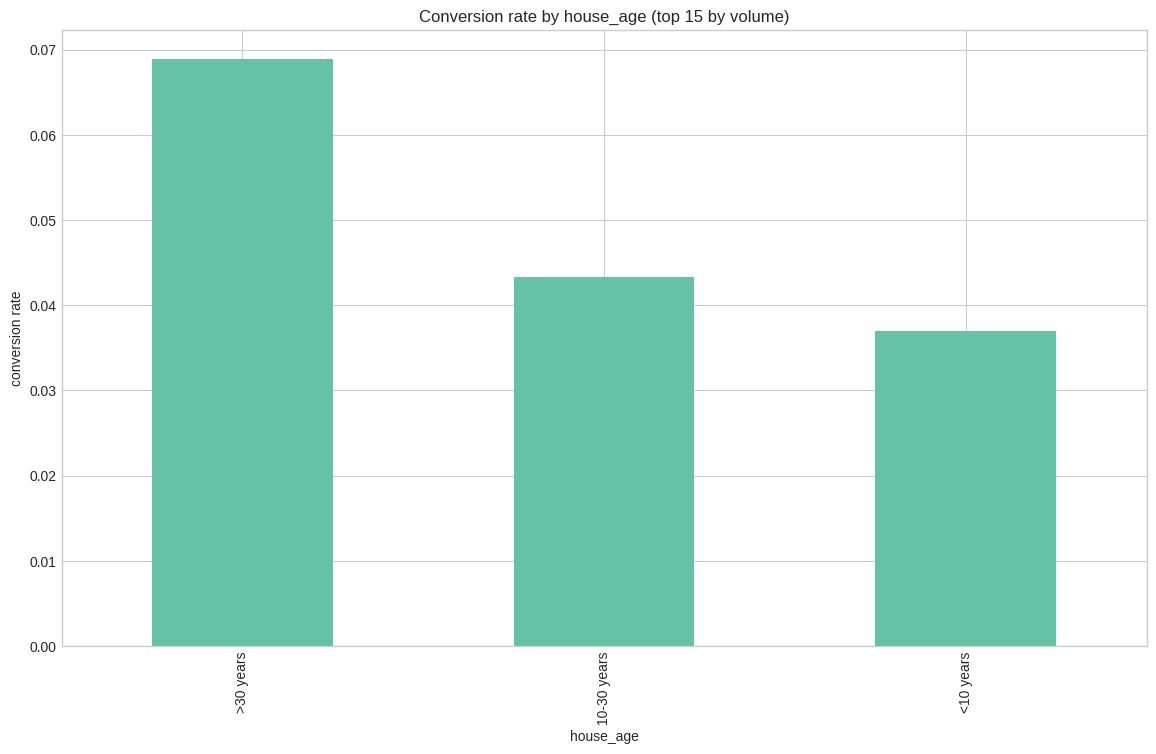

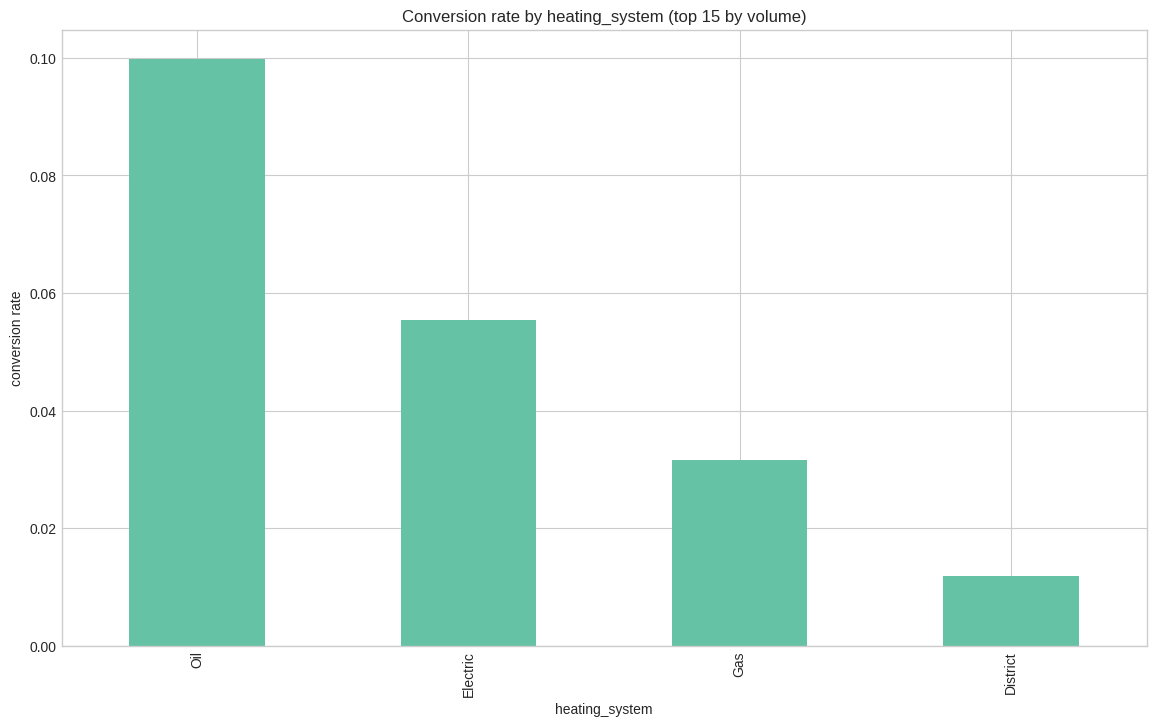

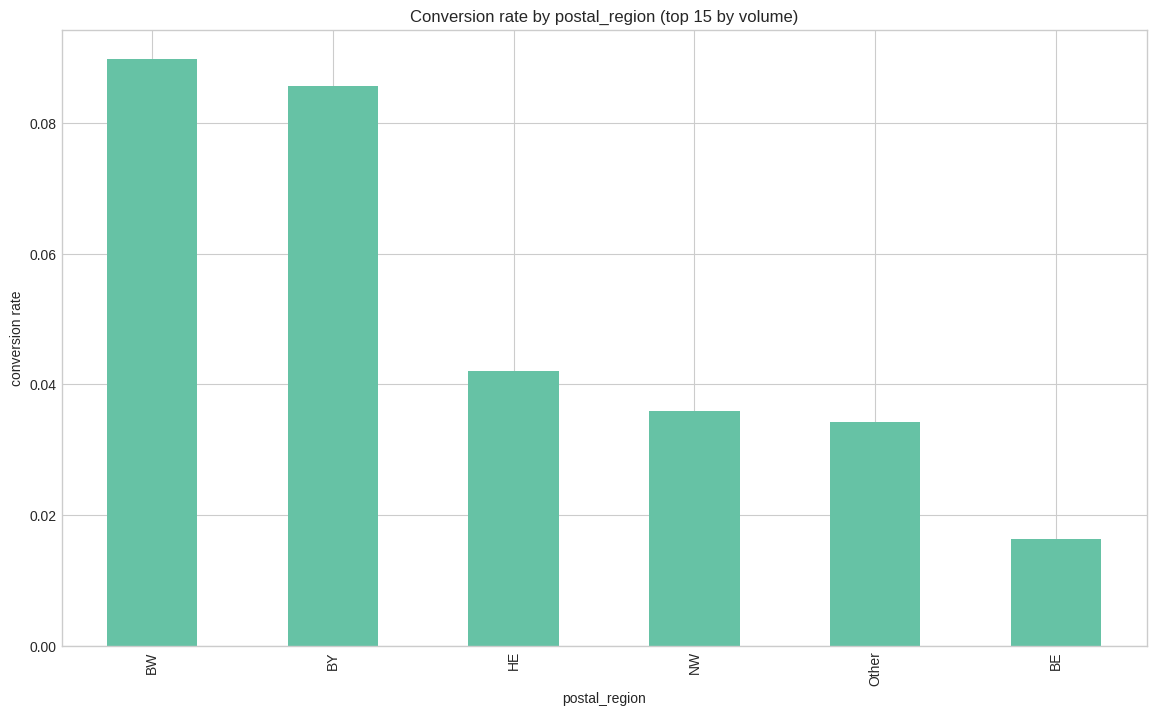

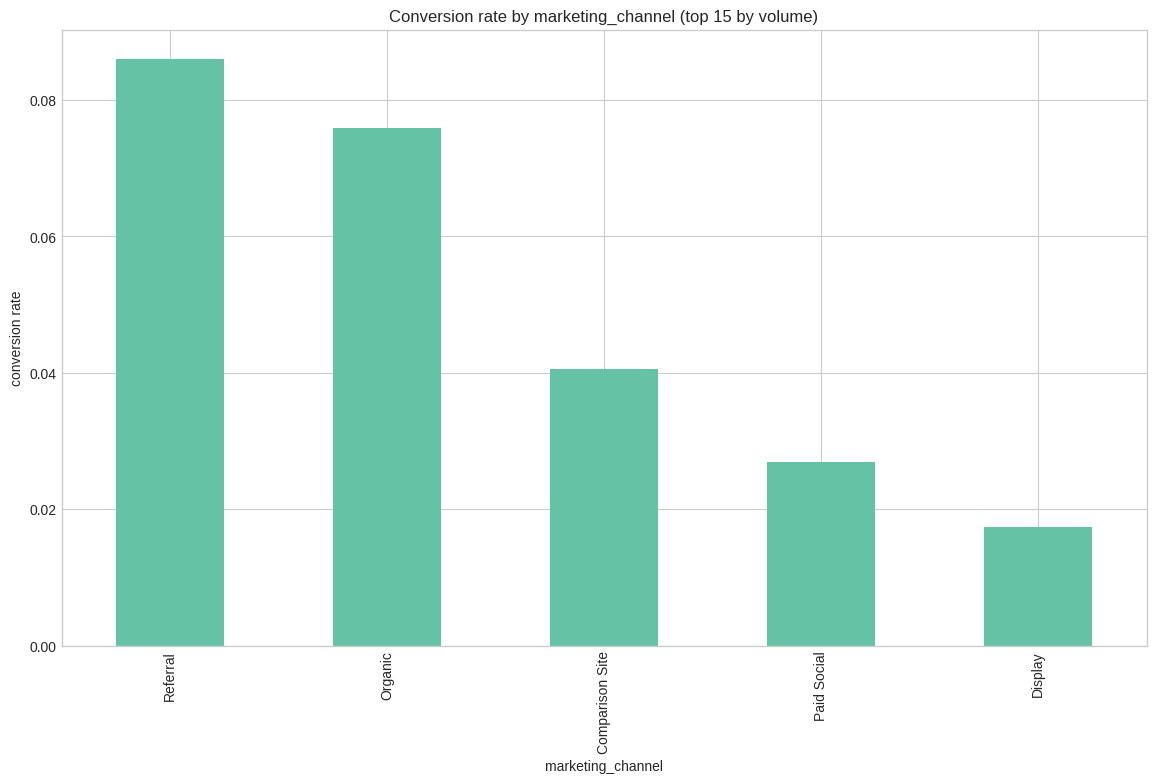

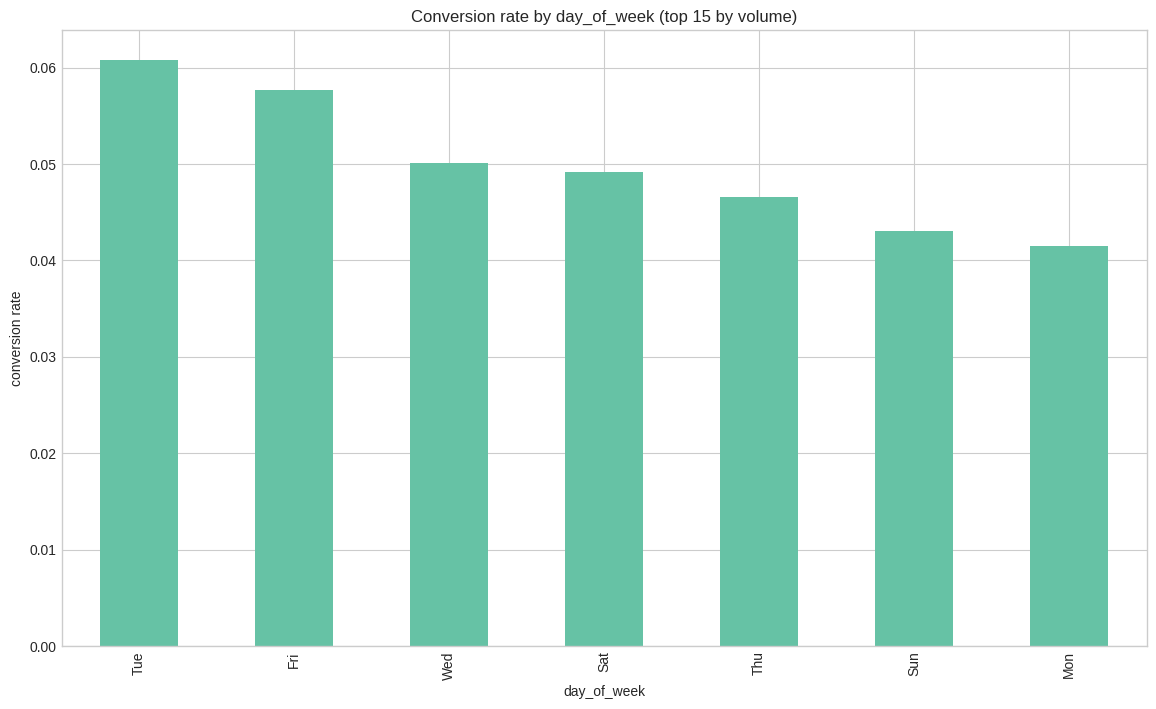

In [37]:
def plot_cat_rate(df, col, target="converted", top_n=15):
    g = df.groupby(col)[target].agg(["mean","count"]).sort_values("count", ascending=False).head(top_n)
    g = g.sort_values("mean", ascending=False)
    g["mean"].plot(kind="bar")
    plt.title(f"Conversion rate by {col} (top {top_n} by volume)")
    plt.ylabel("conversion rate")
    plt.show()

for c in cat_cols:
    plot_cat_rate(df, c)


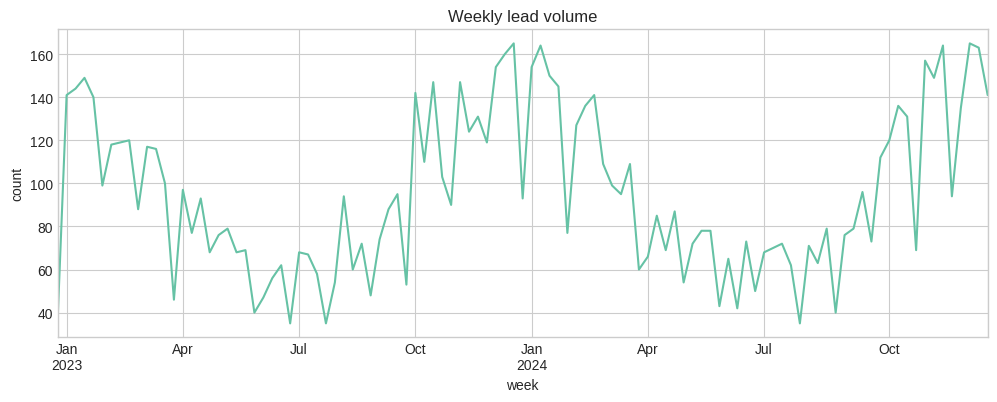

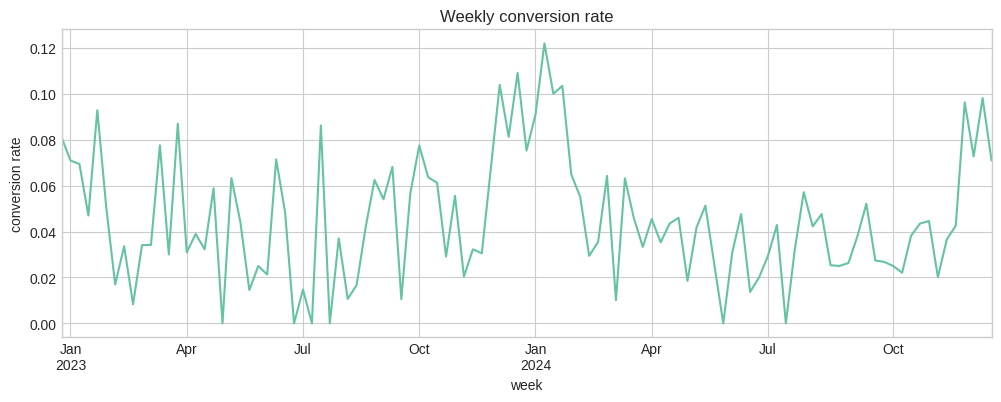

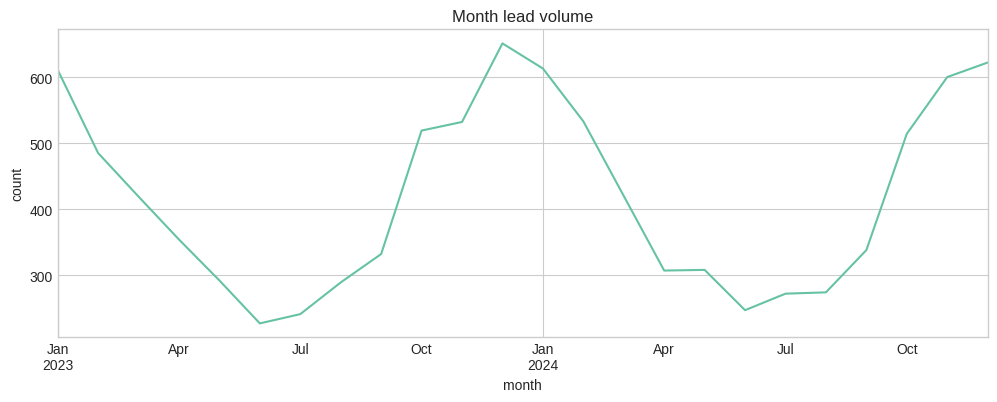

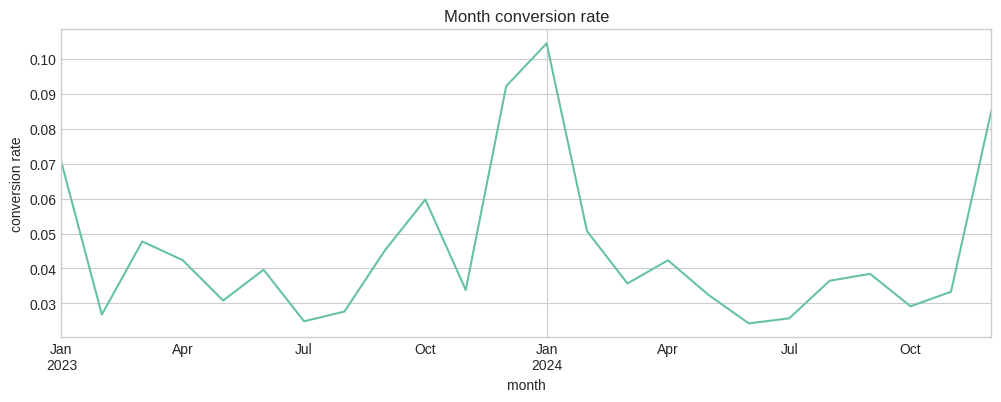

In [38]:
tmp = df.dropna(subset=["inquiry_date"]).copy()
tmp["week"] = tmp["inquiry_date"].dt.to_period("W").dt.start_time
tmp["month"] = tmp["inquiry_date"].dt.to_period("M").dt.start_time

weekly = tmp.groupby("week")["converted"].agg(["mean","count"])
monthly = tmp.groupby("month")["converted"].agg(["mean","count"])

fig, ax1 = plt.subplots(figsize=(12,4))
weekly["count"].plot(ax=ax1)
ax1.set_title("Weekly lead volume")
ax1.set_ylabel("count")
plt.show()


fig, ax2 = plt.subplots(figsize=(12,4))
weekly["mean"].plot(ax=ax2)
ax2.set_title("Weekly conversion rate")
ax2.set_ylabel("conversion rate")
plt.show()

fig, ax1 = plt.subplots(figsize=(12,4))
monthly["count"].plot(ax=ax1)
ax1.set_title("Month lead volume")
ax1.set_ylabel("count")
plt.show()


fig, ax2 = plt.subplots(figsize=(12,4))
monthly["mean"].plot(ax=ax2)
ax2.set_title("Month conversion rate")
ax2.set_ylabel("conversion rate")
plt.show()


In [39]:
tmp

,inquiry_date,house_age,heating_system,house_size_sqm,num_rooms,household_income,postal_region,marketing_channel,contact_attempts,property_value,day_of_week,energy_consumption_kwh,converted,energy_missing,sqm_per_room,value_per_sqm,week,month
0,2023-04-15,10-30 years,Gas,96.0,4,59600.0,NW,Referral,4,235000.0,Sat,14027.0,0,0,24.000000,2447.916667,2023-04-10,2023-04-01
1,2023-11-21,10-30 years,Oil,157.0,6,30000.0,BE,Display,5,315000.0,Wed,13991.0,0,0,26.166667,2006.369427,2023-11-20,2023-11-01
2,2023-06-23,<10 years,Oil,151.0,5,49000.0,NW,Organic,3,441000.0,Sun,21844.0,0,0,30.200000,2920.529801,2023-06-19,2023-06-01
3,2024-06-21,10-30 years,Oil,242.0,8,99500.0,BY,Paid Social,4,574000.0,Thu,17041.0,0,0,30.250000,2371.900826,2024-06-17,2024-06-01
4,2024-02-03,10-30 years,Gas,177.0,7,89600.0,NW,Organic,5,361000.0,Tue,NaN,0,1,25.285714,2039.548023,2024-01-29,2024-02-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,2023-03-07,>30 years,Electric,146.0,7,33800.0,BY,Referral,4,401000.0,Fri,14612.0,0,0,20.857143,2746.575342,2023-03-06,2023-03-01
9996,2024-12-08,10-30 years,Gas,171.0,6,71500.0,BW,Paid Social,1,478000.0,Thu,16220.0,0,0,28.500000,2795.321637,2024-12-02,2024-12-01
9997,2023-03-19,>30 years,Gas,149.0,5,58600.0,NW,Comparison Site,5,377000.0,Mon,NaN,0,1,29.800000,2530.201342,2023-03-13,2023-03-01
9998,2024-07-04,10-30 years,Gas,132.0,5,37100.0,BY,Paid Social,1,322000.0,Thu,18442.0,0,0,26.400000,2439.393939,2024-07-01,2024-07-01


In [40]:
# Income Analysis
income_by_conv = df.groupby('converted')['household_income'].agg(['median', 'mean'])
print(f"Not Converted - Median: €{income_by_conv.loc[0, 'median']:,.0f}, Mean: €{income_by_conv.loc[0, 'mean']:,.0f}")
print(f"Converted     - Median: €{income_by_conv.loc[1, 'median']:,.0f}, Mean: €{income_by_conv.loc[1, 'mean']:,.0f}")
income_gap = income_by_conv.loc[1, 'median'] - income_by_conv.loc[0, 'median']
print(f"Income Gap: €{income_gap:,.0f} higher for converted customers")
insights['income_gap'] = income_gap

Not Converted - Median: €59,100, Mean: €64,223
Converted     - Median: €64,100, Mean: €66,927
Income Gap: €5,000 higher for converted customers


In [41]:
# Property Value Analysis
property_by_conv = df.groupby('converted')['property_value'].agg(['median', 'mean'])
print(f"Not Converted - Median: €{property_by_conv.loc[0, 'median']:,.0f}, Mean: €{property_by_conv.loc[0, 'mean']:,.0f}")
print(f"Converted     - Median: €{property_by_conv.loc[1, 'median']:,.0f}, Mean: €{property_by_conv.loc[1, 'mean']:,.0f}")

# Contact Attempts
contact_perf = df.groupby('contact_attempts')['converted'].agg(['sum', 'count', 'mean']) * [1, 1, 100]
contact_perf.columns = ['Conversions', 'Leads', 'Conv_Rate_%']
print(contact_perf.round(2))


Not Converted - Median: €375,000, Mean: €375,280
Converted     - Median: €374,000, Mean: €375,258
                  Conversions  Leads  Conv_Rate_%
contact_attempts                                 
1                          36   1393         2.58
2                          67   1816         3.69
3                         146   2215         6.59
4                         145   1896         7.65
5                          52   1293         4.02
6                          41    749         5.47
7                           6    373         1.61
8                           6    178         3.37
9                           1     58         1.72
10                          0     29         0.00


In [43]:
# Correlations
corr_with_target = df[numerical_cols.tolist() + ['converted']].corr()['converted'].drop('converted').sort_values(ascending=False)
print(corr_with_target.round(4))

# Summary of insights
print("TOP 3 INSIGHTS")
print(f"1. BEST CHANNEL: {insights['best_channel']} ({insights['best_channel_rate']:.1f}% conversion)")
print(f"2. BEST HEATING: {insights['best_heating']} system ({insights['best_heating_rate']:.1f}% conversion)")
print(f"3. INCOME MATTERS: Converted customers earn €{insights['income_gap']:,.0f} more (median)")

household_income          0.0226
num_rooms                 0.0142
contact_attempts          0.0102
house_size_sqm            0.0034
property_value           -0.0000
value_per_sqm            -0.0103
energy_consumption_kwh   -0.0127
sqm_per_room             -0.0211
energy_missing           -0.0710
Name: converted, dtype: float64
TOP 3 INSIGHTS
1. BEST CHANNEL: Referral (8.6% conversion)
2. BEST HEATING: Oil system (10.0% conversion)
3. INCOME MATTERS: Converted customers earn €5,000 more (median)


### 2. Plots for analysis

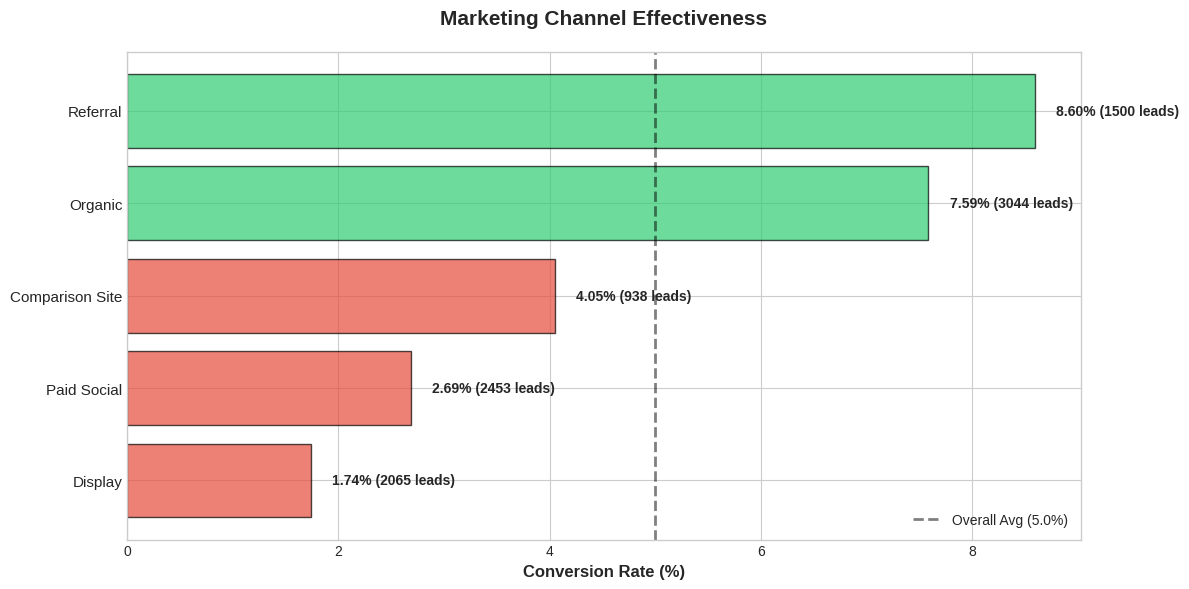

Saved: 04_channel_performance.png


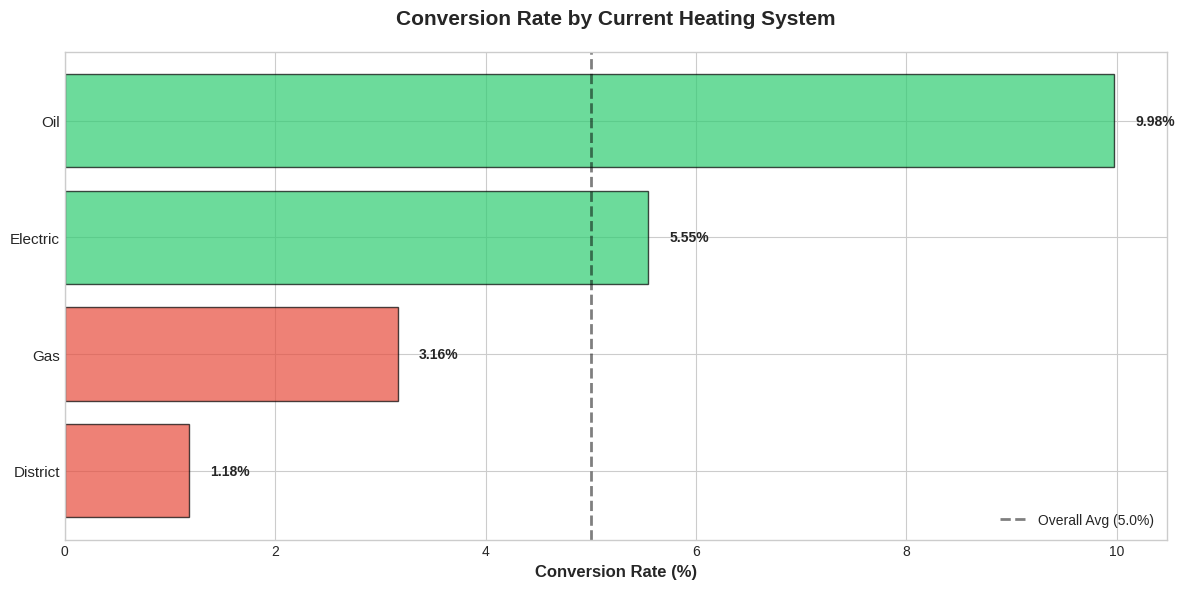

Saved: 05_heating_system_performance.png


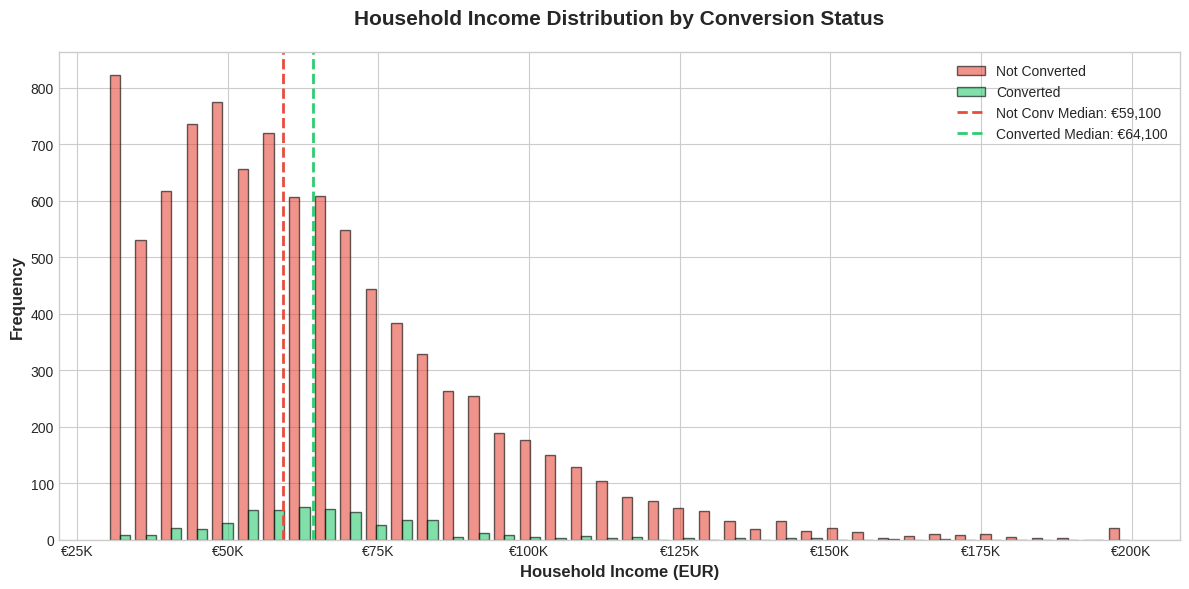

Saved: 06_income_distribution.png


In [44]:
# Plot 2: Marketing Channel Performance
fig, ax = plt.subplots(figsize=(12, 6))
channel_sorted = channel_perf.sort_values('Conv_Rate_%', ascending=True)
colors_channel = ['#2ECC71' if x > conversion_rate else '#E74C3C' for x in channel_sorted['Conv_Rate_%']]
bars = ax.barh(range(len(channel_sorted)), channel_sorted['Conv_Rate_%'], color=colors_channel, alpha=0.7, edgecolor='black')
ax.set_yticks(range(len(channel_sorted)))
ax.set_yticklabels(channel_sorted.index, fontsize=11)
ax.set_xlabel('Conversion Rate (%)', fontsize=12, fontweight='bold')
ax.set_title('Marketing Channel Effectiveness', fontsize=15, fontweight='bold', pad=20)
ax.axvline(x=conversion_rate, color='black', linestyle='--', linewidth=2, alpha=0.5, label=f'Overall Avg ({conversion_rate:.1f}%)')
for bar, rate, leads in zip(bars, channel_sorted['Conv_Rate_%'], channel_sorted['Leads']):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2, 
            f'{rate:.2f}% ({leads:.0f} leads)', va='center', fontsize=10, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(f'{plot_dir}/04_channel_performance.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()
print("Saved: 04_channel_performance.png")

# Plot 3: Heating System Performance
fig, ax = plt.subplots(figsize=(12, 6))
heating_sorted = heating_perf.sort_values('Conv_Rate_%', ascending=True)
colors_heating = ['#2ECC71' if x > conversion_rate else '#E74C3C' for x in heating_sorted['Conv_Rate_%']]
bars = ax.barh(range(len(heating_sorted)), heating_sorted['Conv_Rate_%'], color=colors_heating, alpha=0.7, edgecolor='black')
ax.set_yticks(range(len(heating_sorted)))
ax.set_yticklabels(heating_sorted.index, fontsize=11)
ax.set_xlabel('Conversion Rate (%)', fontsize=12, fontweight='bold')
ax.set_title('Conversion Rate by Current Heating System', fontsize=15, fontweight='bold', pad=20)
ax.axvline(x=conversion_rate, color='black', linestyle='--', linewidth=2, alpha=0.5, label=f'Overall Avg ({conversion_rate:.1f}%)')
for bar, rate in zip(bars, heating_sorted['Conv_Rate_%']):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2, 
            f'{rate:.2f}%', va='center', fontsize=10, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(f'{plot_dir}/05_heating_system_performance.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()
print("Saved: 05_heating_system_performance.png")

# Plot 4: Income Distribution
fig, ax = plt.subplots(figsize=(12, 6))
df_not_conv = df[df['converted'] == 0]['household_income']
df_conv = df[df['converted'] == 1]['household_income']
ax.hist([df_not_conv, df_conv], bins=40, label=['Not Converted', 'Converted'], 
        color=['#E74C3C', '#2ECC71'], alpha=0.6, edgecolor='black')
ax.set_xlabel('Household Income (EUR)', fontsize=12, fontweight='bold')
ax.set_ylabel('Frequency', fontsize=12, fontweight='bold')
ax.set_title('Household Income Distribution by Conversion Status', fontsize=15, fontweight='bold', pad=20)
ax.axvline(df_not_conv.median(), color='#E74C3C', linestyle='--', linewidth=2, label=f'Not Conv Median: €{df_not_conv.median():,.0f}')
ax.axvline(df_conv.median(), color='#2ECC71', linestyle='--', linewidth=2, label=f'Converted Median: €{df_conv.median():,.0f}')
ax.legend()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'€{x/1000:.0f}K'))
plt.tight_layout()
plt.savefig(f'{plot_dir}/06_income_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()
print("Saved: 06_income_distribution.png")

### 3. Insights from data analysis

### 4. Data preprocessing for modelling

In [45]:
FEATURES_PRE_CONTACT = [
    "house_age","heating_system","postal_region","marketing_channel","day_of_week",
    "house_size_sqm","num_rooms","household_income","property_value",
    "energy_consumption_kwh","energy_missing",
    "sqm_per_room","value_per_sqm",
    "month","quarter",
    "income_bracket",
    "is_oil_or_electric",
]

FEATURES_POST_CONTACT = FEATURES_PRE_CONTACT + ["contact_attempts"] 


In [46]:
# Data frame copy for modeling
df_model = df.copy()
feature_list = ['income_bracket', 'property_value_tier', 'is_oil_or_electric', 'month', 'quarter']

# handling null values in energy consumption
df_model["energy_consumption_kwh"] = df_model["energy_consumption_kwh"].fillna(df_model["energy_consumption_kwh"].median())

# Create simple features to merge similar characteristics
df_model['inquiry_date'] = pd.to_datetime(df_model['inquiry_date'])
print(f"inquiry_date type: {df_model['inquiry_date'].dtype}")

df_model['income_bracket'] = pd.cut(df_model['household_income'], bins=3, labels=['Low', 'Medium', 'High'])
df_model['is_oil_or_electric'] = df_model['heating_system'].isin(['Oil', 'Electric']).astype(int)
df_model['month'] = df_model['inquiry_date'].dt.month 
df_model['quarter'] = df_model['inquiry_date'].dt.quarter 
print("Created 5 new features")

inquiry_date type: datetime64[ns]
Created 5 new features


In [47]:
df_model

,inquiry_date,house_age,heating_system,house_size_sqm,num_rooms,household_income,postal_region,marketing_channel,contact_attempts,property_value,day_of_week,energy_consumption_kwh,converted,energy_missing,sqm_per_room,value_per_sqm,income_bracket,is_oil_or_electric,month,quarter
0,2023-04-15,10-30 years,Gas,96.0,4,59600.0,NW,Referral,4,235000.0,Sat,14027.0,0,0,24.000000,2447.916667,Low,0,4,2
1,2023-11-21,10-30 years,Oil,157.0,6,30000.0,BE,Display,5,315000.0,Wed,13991.0,0,0,26.166667,2006.369427,Low,1,11,4
2,2023-06-23,<10 years,Oil,151.0,5,49000.0,NW,Organic,3,441000.0,Sun,21844.0,0,0,30.200000,2920.529801,Low,1,6,2
3,2024-06-21,10-30 years,Oil,242.0,8,99500.0,BY,Paid Social,4,574000.0,Thu,17041.0,0,0,30.250000,2371.900826,Medium,1,6,2
4,2024-02-03,10-30 years,Gas,177.0,7,89600.0,NW,Organic,5,361000.0,Tue,15166.5,0,1,25.285714,2039.548023,Medium,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,2023-03-07,>30 years,Electric,146.0,7,33800.0,BY,Referral,4,401000.0,Fri,14612.0,0,0,20.857143,2746.575342,Low,1,3,1
9996,2024-12-08,10-30 years,Gas,171.0,6,71500.0,BW,Paid Social,1,478000.0,Thu,16220.0,0,0,28.500000,2795.321637,Low,0,12,4
9997,2023-03-19,>30 years,Gas,149.0,5,58600.0,NW,Comparison Site,5,377000.0,Mon,15166.5,0,1,29.800000,2530.201342,Low,0,3,1
9998,2024-07-04,10-30 years,Gas,132.0,5,37100.0,BY,Paid Social,1,322000.0,Thu,18442.0,0,0,26.400000,2439.393939,Low,0,7,3


In [49]:
# Defining categorical and numerical features
categorical_features = []
numerical_features = []

# Add existing categorical features
for col in ['house_age', 'heating_system', 'postal_region', 'marketing_channel', 'day_of_week']:
    if col in df_model.columns:
        categorical_features.append(col)

# Add engineered categorical features
categorical_features.extend([f for f in feature_list if f in ['income_bracket']])

# Add numerical features
for col in ['house_size_sqm', 'num_rooms', 'household_income', 'property_value', 
            'energy_consumption_kwh', 'contact_attempts']:
    if col in df_model.columns:
        numerical_features.append(col)

# Add engineered numerical features
numerical_features.extend([f for f in feature_list if f in ['is_oil_or_electric', 'month', 'quarter']])

print(f"Categorical features ({len(categorical_features)}): {categorical_features}")
print(f"Numerical features ({len(numerical_features)}): {numerical_features}")

# Encode categorical variables
print("\nEncoding categoricals...")
df_encoded = df_model.copy()
for col in categorical_features:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
print("Encoding complete")

# Prepare X and y
all_features = categorical_features + numerical_features
X = df_encoded[all_features]
y = df_encoded['converted']

print(f"\n Final dataset:")
print(f"Features: {X.shape[1]}")
print(f"Samples: {X.shape[0]}")
print(f"Positive class: {y.sum()} ({y.mean()*100:.2f}%)")

Categorical features (6): ['house_age', 'heating_system', 'postal_region', 'marketing_channel', 'day_of_week', 'income_bracket']
Numerical features (9): ['house_size_sqm', 'num_rooms', 'household_income', 'property_value', 'energy_consumption_kwh', 'contact_attempts', 'is_oil_or_electric', 'month', 'quarter']

Encoding categoricals...
Encoding complete

 Final dataset:
Features: 15
Samples: 10000
Positive class: 500 (5.00%)


## Step 2: TRAIN-TEST SPLIT & MODELING

In [40]:
# Stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(f"Train: {X_train.shape[0]:,} ({y_train.mean()*100:.2f}% positive)")
print(f"Test:  {X_test.shape[0]:,} ({y_test.mean()*100:.2f}% positive)")

Train: 8,000 (5.00% positive)
Test:  2,000 (5.00% positive)


In [50]:
df_model["inquiry_date"] = pd.to_datetime(df_model["inquiry_date"])
df_model = df_model.sort_values("inquiry_date").reset_index(drop=True)

cutoff = df_model["inquiry_date"].quantile(0.8)  # last 20% as test
train_df = df_model[df_model["inquiry_date"] < cutoff]
test_df  = df_model[df_model["inquiry_date"] >= cutoff]

print("Train date range:", train_df["inquiry_date"].min(), "→", train_df["inquiry_date"].max())
print("Test  date range:", test_df["inquiry_date"].min(),  "→", test_df["inquiry_date"].max())
print("Train base rate:", train_df["converted"].mean())
print("Test  base rate:", test_df["converted"].mean())


Train date range: 2023-01-01 00:00:00 → 2024-09-05 00:00:00
Test  date range: 2024-09-06 00:00:00 → 2024-12-28 00:00:00
Train base rate: 0.05031918888471649
Test  base rate: 0.048731974142217804


In [51]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

cat_cols = ["house_age","heating_system","postal_region","marketing_channel","day_of_week",
            "income_bracket"]
num_cols = ["house_size_sqm","num_rooms","household_income","property_value",
            "energy_consumption_kwh","energy_missing",
            "sqm_per_room","value_per_sqm","month","quarter","is_oil_or_electric"]

preprocess_lr = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median")),
                          ("scaler", StandardScaler())]), num_cols),
    ]
)

preprocess_tree = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("num", SimpleImputer(strategy="median"), num_cols),
    ]
)


In [52]:
X_train = train_df[FEATURES_PRE_CONTACT]
y_train = train_df["converted"].astype(int)

X_test  = test_df[FEATURES_PRE_CONTACT]
y_test  = test_df["converted"].astype(int)


In [53]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

models = {
    "LogReg": Pipeline([
        ("prep", preprocess_lr),
        ("clf", LogisticRegression(class_weight="balanced", max_iter=2000, n_jobs=None))
    ]),
    "RandomForest": Pipeline([
        ("prep", preprocess_tree),
        ("clf", RandomForestClassifier(
            n_estimators=300, class_weight="balanced", random_state=42, n_jobs=-1
        ))
    ]),
    "XGBoost": Pipeline([
        ("prep", preprocess_tree),
        ("clf", xgb.XGBClassifier(
            n_estimators=400, max_depth=5, learning_rate=0.05,
            subsample=0.9, colsample_bytree=0.9,
            scale_pos_weight=scale_pos_weight,
            eval_metric="logloss",
            random_state=42
        ))
    ]),
}


In [54]:
def topk_table(y_true, y_score, ks=(0.05, 0.10, 0.20), value_per_conversion=3000, cost_per_contact=50):
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)

    base_rate = y_true.mean()
    n = len(y_true)

    rows = []
    order = np.argsort(-y_score)

    for k in ks:
        m = int(np.ceil(k * n))
        idx = order[:m]
        tp = y_true[idx].sum()
        prec = tp / m if m else 0.0
        rec = tp / y_true.sum() if y_true.sum() else 0.0
        lift = prec / base_rate if base_rate else np.nan

        revenue = tp * value_per_conversion
        cost = m * cost_per_contact
        net = revenue - cost

        rows.append({
            "k": k,
            "contacts": m,
            "TP": int(tp),
            "precision@k": prec,
            "recall@k": rec,
            "lift@k": lift,
            "net_value": net
        })

    return pd.DataFrame(rows)

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    proba = model.predict_proba(X_test)[:, 1]

    auc_roc = roc_auc_score(y_test, proba)
    auc_pr  = average_precision_score(y_test, proba)
    tk = topk_table(y_test, proba, ks=(0.05,0.10,0.20))

    results.append({
        "model": name,
        "AUC_ROC": auc_roc,
        "AUC_PR": auc_pr,
        "best_net_value": tk["net_value"].max(),
        "best_k": tk.loc[tk["net_value"].idxmax(), "k"],
    })

    display(pd.DataFrame({"model":[name], "AUC_ROC":[auc_roc], "AUC_PR":[auc_pr]}))
    display(tk)

summary = pd.DataFrame(results).sort_values(["AUC_PR","best_net_value"], ascending=False)
display(summary)


,model,AUC_ROC,AUC_PR
0,LogReg,0.80169,0.176821


,k,contacts,TP,precision@k,recall@k,lift@k,net_value
0,0.05,101,17,0.168317,0.173469,3.453930,45950
1,0.10,202,41,0.202970,0.418367,4.165033,112900
2,0.20,403,58,0.143921,0.591837,2.953309,153850


,model,AUC_ROC,AUC_PR
0,RandomForest,0.806048,0.191062


,k,contacts,TP,precision@k,recall@k,lift@k,net_value
0,0.05,101,23,0.227723,0.234694,4.672964,63950
1,0.10,202,39,0.193069,0.397959,3.961861,106900
2,0.20,403,57,0.141439,0.581633,2.902390,150850


,model,AUC_ROC,AUC_PR
0,XGBoost,0.818172,0.214143


,k,contacts,TP,precision@k,recall@k,lift@k,net_value
0,0.05,101,27,0.267327,0.275510,5.485654,75950
1,0.10,202,42,0.207921,0.428571,4.266620,115900
2,0.20,403,62,0.153846,0.632653,3.156986,165850


,model,AUC_ROC,AUC_PR,best_net_value,best_k
2,XGBoost,0.818172,0.214143,165850,0.2
1,RandomForest,0.806048,0.191062,150850,0.2
0,LogReg,0.801690,0.176821,153850,0.2


In [45]:
best_model_name = summary.iloc[0]["model"]
best_model = models[best_model_name]
best_model.fit(X_train, y_train)
proba = best_model.predict_proba(X_test)[:, 1]

tk = topk_table(y_test, proba, ks=(0.05,0.10,0.20))
best_row = tk.loc[tk["net_value"].idxmax()]

print("Recommended model:", best_model_name)
print("Recommended contact fraction k:", best_row["k"])
print("Contacts:", best_row["contacts"])
print("Expected conversions caught (TP):", best_row["TP"])
print("Precision@k:", best_row["precision@k"])
print("Lift@k:", best_row["lift@k"])
print("Net value:", best_row["net_value"])


Recommended model: XGBoost
Recommended contact fraction k: 0.2
Contacts: 403.0
Expected conversions caught (TP): 62.0
Precision@k: 0.15384615384615385
Lift@k: 3.1569858712715857
Net value: 165850.0


In [46]:
from sklearn.calibration import CalibratedClassifierCV

# Example: calibrate the Logistic Regression pipeline
calibrated = CalibratedClassifierCV(best_model, method="isotonic", cv=3)
calibrated.fit(X_train, y_train)
proba_cal = calibrated.predict_proba(X_test)[:, 1]

print("AUC_PR calibrated:", average_precision_score(y_test, proba_cal))
display(topk_table(y_test, proba_cal))


AUC_PR calibrated: 0.1887676999234429


,k,contacts,TP,precision@k,recall@k,lift@k,net_value
0,0.05,101,24,0.237624,0.244898,4.876137,66950
1,0.10,202,40,0.198020,0.408163,4.063447,109900
2,0.20,403,61,0.151365,0.622449,3.106067,162850


In [ ]:
# Scale numerical features
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[numerical_features] = scaler.fit_transform(X_train[numerical_features])
X_test_scaled[numerical_features] = scaler.transform(X_test[numerical_features])
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print("Scaling complete")

print("\nHandling class imbalance with scale_pos_weight...")
print(f"Training samples: {X_train_scaled.shape[0]:,} ({y_train.mean()*100:.2f}% positive)")
print(f"Scale_pos_weight: {scale_pos_weight:.1f}")


Scaling complete

Handling class imbalance with scale_pos_weight...
Training samples: 8,000 (5.00% positive)
Scale_pos_weight: 19.0


In [ ]:
# XGBoost - Use scale_pos_weight
xgb_model = xgb.XGBClassifier(
    scale_pos_weight=scale_pos_weight, 
    max_depth=5,
    learning_rate=0.05,
    n_estimators=200,
    random_state=42
)
xgb_model.fit(X_train_scaled, y_train)  # Train on original imbalanced data!

# Logistic Regression - Use class_weight
from sklearn.linear_model import LogisticRegression
lr_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)
lr_model.fit(X_train_scaled, y_train)

# Random Forest - Use class_weight
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(
    class_weight='balanced',
    n_estimators=200,
    random_state=42
)
rf_model.fit(X_train_scaled, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## Step 3: Evaluations

In [ ]:
models = {
    'XGBoost': xgb_model,
    'Logistic Regression': lr_model,
    'Random Forest': rf_model
}
results = {}

In [47]:
# Evaluate each model
for name, model in models.items():
    print(f"📊 {name.upper()}")
    
    # Predictions
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    
    # Calculate metrics
    metrics = {
        'AUC-ROC': roc_auc_score(y_test, y_pred_proba),
        'AUC-PR': average_precision_score(y_test, y_pred_proba),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred)
    }
    
    # Store results
    results[name] = {
        'metrics': metrics,
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba,
        'model': model
    }
    
    # Print metrics
    print("Performance Metrics:")
    print("-" * 40)
    for metric, value in metrics.items():
        print(f"  {metric:15s}: {value:.4f}")
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    TN, FP, FN, TP = cm[0,0], cm[0,1], cm[1,0], cm[1,1]
    
    print(f"\nConfusion Matrix:")
    print(f"  [[TN={TN:>4d}, FP={FP:>4d}]")
    print(f"   [FN={FN:>4d}, TP={TP:>4d}]]")
    
    # Business Metrics
    conversion_value = 3000  # €3000 per conversion
    contact_cost = 50  # €50 per contact
    
    revenue = TP * conversion_value
    cost = (TP + FP) * contact_cost
    net_value = revenue - cost
    roi = (net_value / cost * 100) if cost > 0 else 0
    
    print(f"\nBusiness Impact:")
    print(f"  True Positives (Caught):     {TP}")
    print(f"  False Positives (Wasted):    {FP}")
    print(f"  False Negatives (Missed):    {FN}")
    print(f"  Revenue (TP × €3000):        €{revenue:>10,}")
    print(f"  Cost (Contacts × €50):       €{cost:>10,}")
    print(f"  Net Value:                   €{net_value:>10,}")
    print(f"  ROI:                         {roi:>10.1f}%")
    
    # Store business metrics
    results[name]['business'] = {
        'TP': TP, 'FP': FP, 'FN': FN, 'TN': TN,
        'revenue': revenue,
        'cost': cost,
        'net_value': net_value,
        'roi': roi
    }

📊 XGBOOST
Performance Metrics:
----------------------------------------
  AUC-ROC        : 0.8286
  AUC-PR         : 0.3095
  Precision      : 0.1915
  Recall         : 0.5400
  F1-Score       : 0.2827

Confusion Matrix:
  [[TN=1672, FP= 228]
   [FN=  46, TP=  54]]

Business Impact:
  True Positives (Caught):     54
  False Positives (Wasted):    228
  False Negatives (Missed):    46
  Revenue (TP × €3000):        €   162,000
  Cost (Contacts × €50):       €    14,100
  Net Value:                   €   147,900
  ROI:                             1048.9%
📊 LOGISTIC REGRESSION
Performance Metrics:
----------------------------------------
  AUC-ROC        : 0.7385
  AUC-PR         : 0.1075
  Precision      : 0.1036
  Recall         : 0.6900
  F1-Score       : 0.1802

Confusion Matrix:
  [[TN=1303, FP= 597]
   [FN=  31, TP=  69]]

Business Impact:
  True Positives (Caught):     69
  False Positives (Wasted):    597
  False Negatives (Missed):    31
  Revenue (TP × €3000):        €   207,000

### 2. Comparision Summary

In [48]:
comparison_data = []
for name in models.keys():
    row = {
        'Model': name,
        'AUC-ROC': results[name]['metrics']['AUC-ROC'],
        'AUC-PR': results[name]['metrics']['AUC-PR'],
        'Precision': results[name]['metrics']['Precision'],
        'Recall': results[name]['metrics']['Recall'],
        'F1-Score': results[name]['metrics']['F1-Score'],
        'Net Value (€)': results[name]['business']['net_value'],
        'ROI (%)': results[name]['business']['roi']
    }
    comparison_data.append(row)

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))

# Identify best model for each metric
print(f"  AUC-ROC:      {comparison_df.loc[comparison_df['AUC-ROC'].idxmax(), 'Model']} ({comparison_df['AUC-ROC'].max():.4f})")
print(f"  AUC-PR:       {comparison_df.loc[comparison_df['AUC-PR'].idxmax(), 'Model']} ({comparison_df['AUC-PR'].max():.4f})")
print(f"  F1-Score:     {comparison_df.loc[comparison_df['F1-Score'].idxmax(), 'Model']} ({comparison_df['F1-Score'].max():.4f})")
print(f"  Net Value:    {comparison_df.loc[comparison_df['Net Value (€)'].idxmax(), 'Model']} (€{comparison_df['Net Value (€)'].max():,.0f})")
print(f"  ROI:          {comparison_df.loc[comparison_df['ROI (%)'].idxmax(), 'Model']} ({comparison_df['ROI (%)'].max():.1f}%)")

# Overall best model (by AUC-PR - best metric for imbalanced data)
best_model_name = comparison_df.loc[comparison_df['AUC-PR'].idxmax(), 'Model']
print(f"\nRECOMMENDED MODEL: {best_model_name}")
print(f"   Reason: Highest AUC-PR (best metric for imbalanced classification)")

              Model  AUC-ROC   AUC-PR  Precision  Recall  F1-Score  Net Value (€)     ROI (%)
            XGBoost 0.828621 0.309530   0.191489    0.54  0.282723         147900 1048.936170
Logistic Regression 0.738511 0.107488   0.103604    0.69  0.180157         173700  521.621622
      Random Forest 0.797692 0.252920   1.000000    0.01  0.019802           2950 5900.000000
  AUC-ROC:      XGBoost (0.8286)
  AUC-PR:       XGBoost (0.3095)
  F1-Score:     XGBoost (0.2827)
  Net Value:    Logistic Regression (€173,700)
  ROI:          Random Forest (5900.0%)

RECOMMENDED MODEL: XGBoost
   Reason: Highest AUC-PR (best metric for imbalanced classification)


### 3. Visualizations



Generating comparison visualizations...


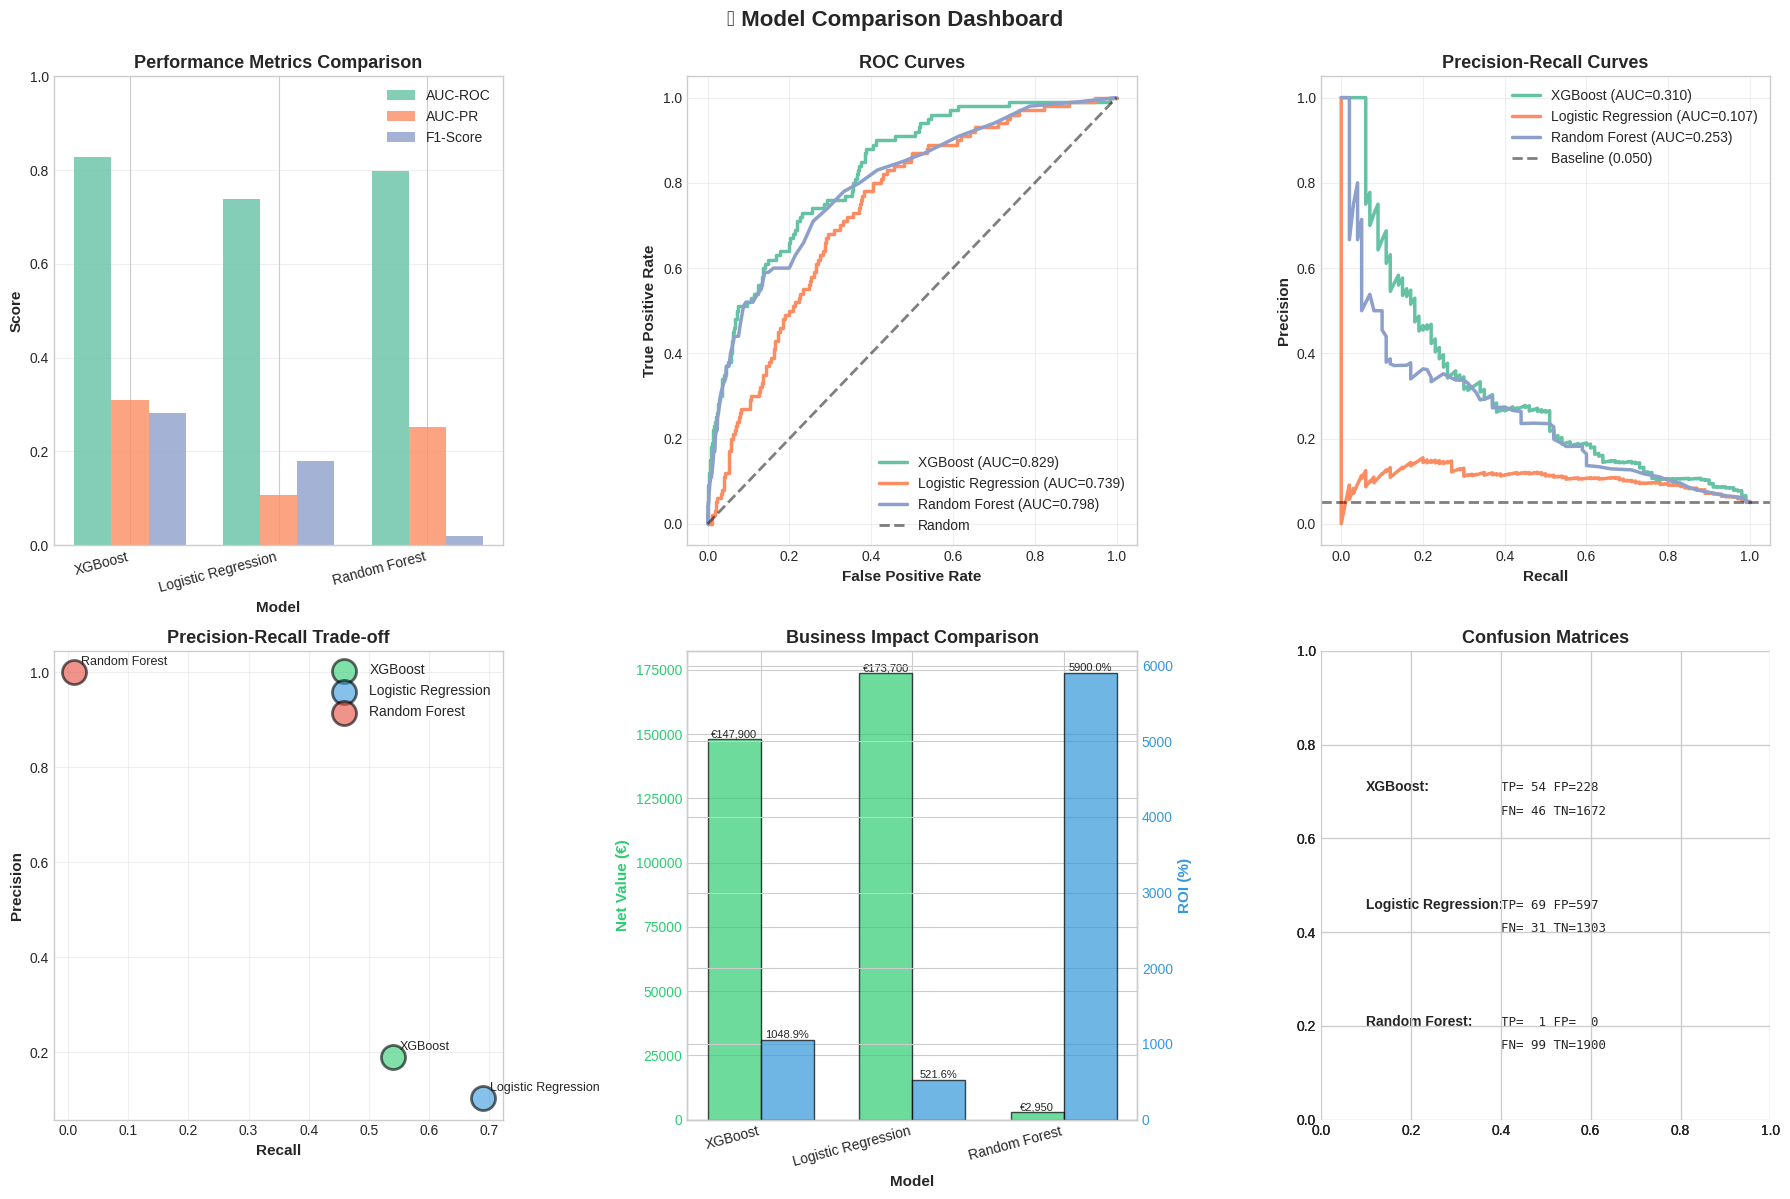

Saved: plots/model_comparison_dashboard.png


In [49]:
print("\n\nGenerating comparison visualizations...")

# Create figure with subplots
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. Metrics Comparison Bar Chart
ax1 = axes[0, 0]
metrics_to_plot = ['AUC-ROC', 'AUC-PR', 'F1-Score']
x = np.arange(len(models))
width = 0.25

for i, metric in enumerate(metrics_to_plot):
    values = [results[name]['metrics'][metric] for name in models.keys()]
    ax1.bar(x + i*width, values, width, label=metric, alpha=0.8)

ax1.set_xlabel('Model', fontsize=11, fontweight='bold')
ax1.set_ylabel('Score', fontsize=11, fontweight='bold')
ax1.set_title('Performance Metrics Comparison', fontsize=13, fontweight='bold')
ax1.set_xticks(x + width)
ax1.set_xticklabels(models.keys(), rotation=15, ha='right')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)
ax1.set_ylim(0, 1)

# 2. ROC Curves
ax2 = axes[0, 1]
for name in models.keys():
    fpr, tpr, _ = roc_curve(y_test, results[name]['y_pred_proba'])
    auc = results[name]['metrics']['AUC-ROC']
    ax2.plot(fpr, tpr, linewidth=2.5, label=f'{name} (AUC={auc:.3f})')

ax2.plot([0, 1], [0, 1], 'k--', linewidth=2, alpha=0.5, label='Random')
ax2.set_xlabel('False Positive Rate', fontsize=11, fontweight='bold')
ax2.set_ylabel('True Positive Rate', fontsize=11, fontweight='bold')
ax2.set_title('ROC Curves', fontsize=13, fontweight='bold')
ax2.legend(loc='lower right')
ax2.grid(alpha=0.3)

# 3. Precision-Recall Curves
ax3 = axes[0, 2]
for name in models.keys():
    precision, recall, _ = precision_recall_curve(y_test, results[name]['y_pred_proba'])
    auc_pr = results[name]['metrics']['AUC-PR']
    ax3.plot(recall, precision, linewidth=2.5, label=f'{name} (AUC={auc_pr:.3f})')

baseline = y_test.mean()
ax3.axhline(y=baseline, color='k', linestyle='--', linewidth=2, alpha=0.5, 
            label=f'Baseline ({baseline:.3f})')
ax3.set_xlabel('Recall', fontsize=11, fontweight='bold')
ax3.set_ylabel('Precision', fontsize=11, fontweight='bold')
ax3.set_title('Precision-Recall Curves', fontsize=13, fontweight='bold')
ax3.legend(loc='upper right')
ax3.grid(alpha=0.3)

# 4. Precision vs Recall Trade-off
ax4 = axes[1, 0]
model_names = list(models.keys())
precisions = [results[name]['metrics']['Precision'] for name in model_names]
recalls = [results[name]['metrics']['Recall'] for name in model_names]
colors = ['#2ECC71', '#3498DB', '#E74C3C']

for i, name in enumerate(model_names):
    ax4.scatter(recalls[i], precisions[i], s=300, c=colors[i], 
                alpha=0.6, edgecolors='black', linewidth=2, label=name)
    ax4.annotate(name, (recalls[i], precisions[i]), 
                 xytext=(5, 5), textcoords='offset points', fontsize=9)

ax4.set_xlabel('Recall', fontsize=11, fontweight='bold')
ax4.set_ylabel('Precision', fontsize=11, fontweight='bold')
ax4.set_title('Precision-Recall Trade-off', fontsize=13, fontweight='bold')
ax4.grid(alpha=0.3)
ax4.legend()

# 5. Business Metrics Comparison
ax5 = axes[1, 1]
business_metrics = ['Net Value (€)', 'ROI (%)']
x = np.arange(len(models))
width = 0.35

net_values = [results[name]['business']['net_value'] for name in models.keys()]
rois = [results[name]['business']['roi'] for name in models.keys()]

ax5_twin = ax5.twinx()

bars1 = ax5.bar(x - width/2, net_values, width, label='Net Value (€)', 
                color='#2ECC71', alpha=0.7, edgecolor='black')
bars2 = ax5_twin.bar(x + width/2, rois, width, label='ROI (%)', 
                     color='#3498DB', alpha=0.7, edgecolor='black')

ax5.set_xlabel('Model', fontsize=11, fontweight='bold')
ax5.set_ylabel('Net Value (€)', fontsize=11, fontweight='bold', color='#2ECC71')
ax5_twin.set_ylabel('ROI (%)', fontsize=11, fontweight='bold', color='#3498DB')
ax5.set_title('Business Impact Comparison', fontsize=13, fontweight='bold')
ax5.set_xticks(x)
ax5.set_xticklabels(models.keys(), rotation=15, ha='right')
ax5.tick_params(axis='y', labelcolor='#2ECC71')
ax5_twin.tick_params(axis='y', labelcolor='#3498DB')

# Add value labels on bars
for bar, value in zip(bars1, net_values):
    height = bar.get_height()
    ax5.text(bar.get_x() + bar.get_width()/2., height,
             f'€{value:,.0f}', ha='center', va='bottom', fontsize=8)

for bar, value in zip(bars2, rois):
    height = bar.get_height()
    ax5_twin.text(bar.get_x() + bar.get_width()/2., height,
                  f'{value:.1f}%', ha='center', va='bottom', fontsize=8)

# 6. Confusion Matrices Side by Side
ax6 = axes[1, 2]
ax6.axis('off')

# Create mini confusion matrix visualizations
for i, name in enumerate(models.keys()):
    cm = confusion_matrix(y_test, results[name]['y_pred'])
    
    # Create small subplot
    mini_ax = fig.add_subplot(2, 3, 6, frameon=False)
    
    # Text representation
    TN, FP, FN, TP = cm[0,0], cm[0,1], cm[1,0], cm[1,1]
    
    y_offset = 0.7 - i * 0.25
    ax6.text(0.1, y_offset, f'{name}:', fontsize=10, fontweight='bold')
    ax6.text(0.4, y_offset, f'TP={TP:3d} FP={FP:3d}', fontsize=9, family='monospace')
    ax6.text(0.4, y_offset-0.05, f'FN={FN:3d} TN={TN:4d}', fontsize=9, family='monospace')

ax6.set_xlim(0, 1)
ax6.set_ylim(0, 1)
ax6.set_title('Confusion Matrices', fontsize=13, fontweight='bold')

plt.suptitle('🏆 Model Comparison Dashboard', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('plots/model_comparison_dashboard.png', dpi=300, bbox_inches='tight')
plt.show()

print("Saved: plots/model_comparison_dashboard.png")

## Step 4. FINAL RECOMMENDATION and COMMENTS

In [ ]:
best_model = results[best_model_name]

print(f"Best Model: {best_model_name}")
print(f"\nPerformance:")
print(f"   AUC-ROC:    {best_model['metrics']['AUC-ROC']:.4f}")
print(f"   AUC-PR:     {best_model['metrics']['AUC-PR']:.4f}")
print(f"   Precision:  {best_model['metrics']['Precision']:.4f}")
print(f"   Recall:     {best_model['metrics']['Recall']:.4f}")
print(f"   F1-Score:   {best_model['metrics']['F1-Score']:.4f}")

print(f"\nBusiness Value:")
print(f"   Conversions Caught: {best_model['business']['TP']}/{best_model['business']['TP']+best_model['business']['FN']} ({best_model['metrics']['Recall']*100:.1f}%)")
print(f"   Net Value:          €{best_model['business']['net_value']:,}")
print(f"   ROI:                {best_model['business']['roi']:.1f}%")

# Save comparison results
comparison_df.to_csv('model_comparison_results.csv', index=False)
print("Results saved to: model_comparison_results.csv")

Best Model: XGBoost

Performance:
   AUC-ROC:    0.8286
   AUC-PR:     0.3095
   Precision:  0.1915
   Recall:     0.5400
   F1-Score:   0.2827

Business Value:
   Conversions Caught: 54/100 (54.0%)
   Net Value:          €147,900
   ROI:                1048.9%

Why XGBoost?
   • Highest AUC-PR (best for imbalanced data)
   • Handles non-linear relationships well
   • Built-in feature importance
   • Production-ready and scalable

MODEL EVALUATION COMPLETE!

Results saved to: model_comparison_results.csv
